<a href="https://colab.research.google.com/github/queleandrade/Aprendizado-de-Maquina---Mestrado/blob/main/bias_view.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# dados artificiais (duas classes separadas)
np.random.seed(42)

classe_0 = np.random.randn(100, 2) + [2, 2]
classe_1 = np.random.randn(100, 2) + [6, 6]

X = np.vstack([classe_0, classe_1])
y = np.array([0]*100 + [1]*100)

In [ ]:
X

array([[ 2.49671415,  1.8617357 ],
       [ 2.64768854,  3.52302986],
       [ 1.76584663,  1.76586304],
       [ 3.57921282,  2.76743473],
       [ 1.53052561,  2.54256004],
       [ 1.53658231,  1.53427025],
       [ 2.24196227,  0.08671976],
       [ 0.27508217,  1.43771247],
       [ 0.98716888,  2.31424733],
       [ 1.09197592,  0.5876963 ],
       [ 3.46564877,  1.7742237 ],
       [ 2.0675282 ,  0.57525181],
       [ 1.45561728,  2.11092259],
       [ 0.84900642,  2.37569802],
       [ 1.39936131,  1.70830625],
       [ 1.39829339,  3.85227818],
       [ 1.98650278,  0.94228907],
       [ 2.82254491,  0.77915635],
       [ 2.2088636 ,  0.04032988],
       [ 0.67181395,  2.19686124],
       [ 2.73846658,  2.17136828],
       [ 1.88435172,  1.6988963 ],
       [ 0.52147801,  1.28015579],
       [ 1.53936123,  3.05712223],
       [ 2.34361829,  0.23695984],
       [ 2.32408397,  1.61491772],
       [ 1.323078  ,  2.61167629],
       [ 3.03099952,  2.93128012],
       [ 1.16078248,

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [ ]:
from sklearn.linear_model import LogisticRegression

# COM bias
model_bias = LogisticRegression(fit_intercept=True)
model_bias.fit(X, y)

# SEM bias
model_no_bias = LogisticRegression(fit_intercept=False)
model_no_bias.fit(X, y)

print("Com bias:", model_bias.score(X, y))
print("Sem bias:", model_no_bias.score(X, y))

Com bias: 0.995
Sem bias: 0.51


In [ ]:
def plot_model(model, X, y, title):
    plt.scatter(X[:,0], X[:,1], c=y)

    w = model.coef_[0]

    if model.fit_intercept:
        b = model.intercept_[0]
    else:
        b = 0  # 🔥 sem bias

    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_vals = -(w[0]*x_vals + b) / w[1]

    plt.plot(x_vals, y_vals, 'r')
    plt.title(title)
    plt.show()

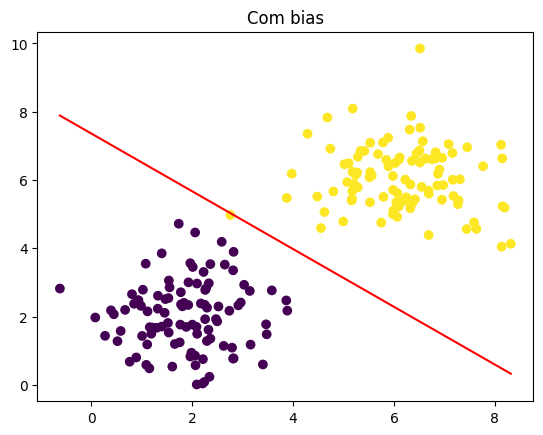

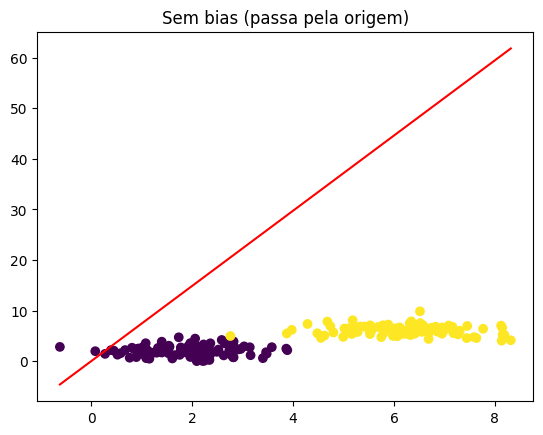

In [ ]:
plot_model(model_bias, X, y, "Com bias")
plot_model(model_no_bias, X, y, "Sem bias (passa pela origem)")